# MRNet Multi-class Kaggle Notebook

This notebook builds a **multi-class** classifier for MRNet using:

- **sagittal plane only**
- **exclusive 4-class labels**
- **paper-style augmentation**
- **ViT / ResNet50 / InceptionV3 comparison**
- **AUC, accuracy, balanced accuracy, macro F1**
- **class-weighted loss**
- optional **focal loss**

## Multi-class label rule
Because MRNet labels overlap, this notebook creates **exclusive labels** using priority:

1. ACL
2. Meniscus
3. Abnormal-other
4. Normal

So each exam gets exactly one class.

## Class mapping
- `0 = acl`
- `1 = meniscus`
- `2 = abnormal_other`
- `3 = normal`

In [1]:
!pip install -q timm

In [2]:

import os
import gc
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as tv_models

import timm

warnings.filterwarnings("ignore")

In [3]:

# Cell 3 — Config

class CFG:
    ROOT = Path("/kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v1.0")

    PLANE = "sagittal"
    IMAGE_SIZE = 224
    BATCH_SIZE = 1
    EPOCHS = 12
    NUM_WORKERS = 2

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SEED = 42

    # Choose one:
    # "resnet50"
    # "inception_v3"
    # "vit_small"
    # "vit_large"
    MODEL_TYPE = "vit_small"

    BACKBONE_LR = 5e-6
    HEAD_LR = 5e-5
    WEIGHT_DECAY = 1e-4
    DROPOUT = 0.5

    VIT_MODEL_NAME = "vit_small_patch16_224"
    VIT_LARGE_MODEL_NAME = "vit_large_patch16_224"
    TRANSFORMER_DEPTH = 4
    TRANSFORMER_HEADS = 8

    USE_FOCAL_LOSS = False
    FOCAL_ALPHA = 1.0
    FOCAL_GAMMA = 2.0

    NUM_CLASSES = 4
    CLASS_NAMES = ["acl", "meniscus", "abnormal_other", "normal"]

print("Device:", CFG.DEVICE)
print("Model type:", CFG.MODEL_TYPE)

Device: cuda
Model type: vit_small


In [4]:

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)

In [5]:

# Cell 5 — Load labels and create multiclass target

def load_split_labels(root, split):
    acl = pd.read_csv(root / f"{split}-acl.csv", header=None, names=["id", "acl"])
    abnormal = pd.read_csv(root / f"{split}-abnormal.csv", header=None, names=["id", "abnormal"])
    meniscus = pd.read_csv(root / f"{split}-meniscus.csv", header=None, names=["id", "meniscus"])

    df = acl.merge(abnormal, on="id").merge(meniscus, on="id")
    df["id"] = df["id"].astype(str).str.zfill(4)
    df["split"] = split
    return df

def make_multiclass_label(row):
    # Priority rule:
    # ACL > Meniscus > Abnormal-other > Normal
    if row["acl"] == 1:
        return 0
    elif row["meniscus"] == 1:
        return 1
    elif row["abnormal"] == 1:
        return 2
    else:
        return 3

def add_paths(df, root, split, plane):
    df = df.copy()
    df["path"] = df["id"].apply(lambda x: str(root / split / plane / f"{x}.npy"))
    return df

train_df = load_split_labels(CFG.ROOT, "train")
valid_df = load_split_labels(CFG.ROOT, "valid")

train_df["label"] = train_df.apply(make_multiclass_label, axis=1)
valid_df["label"] = valid_df.apply(make_multiclass_label, axis=1)

train_df = add_paths(train_df, CFG.ROOT, "train", CFG.PLANE)
valid_df = add_paths(valid_df, CFG.ROOT, "valid", CFG.PLANE)

print(train_df.head())
print(valid_df.head())
print("Train label counts:")
print(train_df["label"].value_counts().sort_index())
print("Valid label counts:")
print(valid_df["label"].value_counts().sort_index())

     id  acl  abnormal  meniscus  split  label  \
0  0000    0         1         0  train      2   
1  0001    1         1         1  train      0   
2  0002    0         1         0  train      2   
3  0003    0         1         1  train      1   
4  0004    0         1         0  train      2   

                                                path  
0  /kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...  
1  /kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...  
2  /kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...  
3  /kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...  
4  /kaggle/input/datasets/cjinny/mrnet-v1/MRNet-v...  
     id  acl  abnormal  meniscus  split  label  \
0  1130    0         0         0  valid      3   
1  1131    0         0         0  valid      3   
2  1132    0         0         0  valid      3   
3  1133    0         0         0  valid      3   
4  1134    0         0         0  valid      3   

                                                path  
0  /kaggle/in

In [6]:

# Cell 6 — Class weights

class_counts = train_df["label"].value_counts().sort_index()
counts_tensor = torch.tensor(class_counts.values, dtype=torch.float32)

class_weights = 1.0 / torch.sqrt(counts_tensor)
class_weights = class_weights / class_weights.sum() * len(class_weights)

print("Class counts:")
print(class_counts)
print("Class weights:", class_weights)
print("Class names:", CFG.CLASS_NAMES)

Class counts:
label
0    208
1    272
2    433
3    217
Name: count, dtype: int64
Class weights: tensor([1.1278, 0.9863, 0.7817, 1.1042])
Class names: ['acl', 'meniscus', 'abnormal_other', 'normal']


In [7]:

# Cell 7 — Preprocessing helpers

def normalize_to_uint8(img):
    img = img.astype(np.float32)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    img = (img * 255.0).clip(0, 255).astype(np.uint8)
    return img

def select_informative_slices(volume, max_slices=None):
    D = volume.shape[0]
    idxs = list(range(D))
    vars_ = [volume[i].var() for i in idxs]
    ranked = [idx for idx, _ in sorted(zip(idxs, vars_), key=lambda x: x[1], reverse=True)]

    if max_slices is not None:
        ranked = ranked[:max_slices]

    ranked = sorted(ranked)
    return ranked

def load_volume_as_pil_list(path, max_slices=None):
    volume = np.load(path)
    idxs = select_informative_slices(volume, max_slices=max_slices)

    images = []
    for idx in idxs:
        img = normalize_to_uint8(volume[idx])
        img = Image.fromarray(img).convert("RGB")
        images.append(img)
    return images, idxs

In [8]:

# Cell 8 — Augmentation

train_tfms = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(
        degrees=25,
        translate=(0.10, 0.10)
    ),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.25, 0.25, 0.25]),
])

valid_tfms = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.25, 0.25, 0.25]),
])

In [9]:

# Cell 9 — Dataset

class MRNetExamDataset(Dataset):
    def __init__(self, df, transforms=None, max_slices=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.max_slices = max_slices

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pil_list, slice_idxs = load_volume_as_pil_list(row["path"], max_slices=self.max_slices)
        imgs = [self.transforms(img) for img in pil_list]
        imgs = torch.stack(imgs, dim=0)  # [S, 3, H, W]
        label = torch.tensor(row["label"], dtype=torch.long)
        return {
            "images": imgs,
            "label": label,
            "id": row["id"],
            "slice_idxs": slice_idxs
        }

train_ds = MRNetExamDataset(train_df, transforms=train_tfms, max_slices=None)
valid_ds = MRNetExamDataset(valid_df, transforms=valid_tfms, max_slices=None)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS,
    pin_memory=True
)

print("Train exams:", len(train_ds))
print("Valid exams:", len(valid_ds))

Train exams: 1130
Valid exams: 120


Exam ID: 0000
Images shape: torch.Size([36, 3, 224, 224])
Label: 2 abnormal_other
Num slices: 36


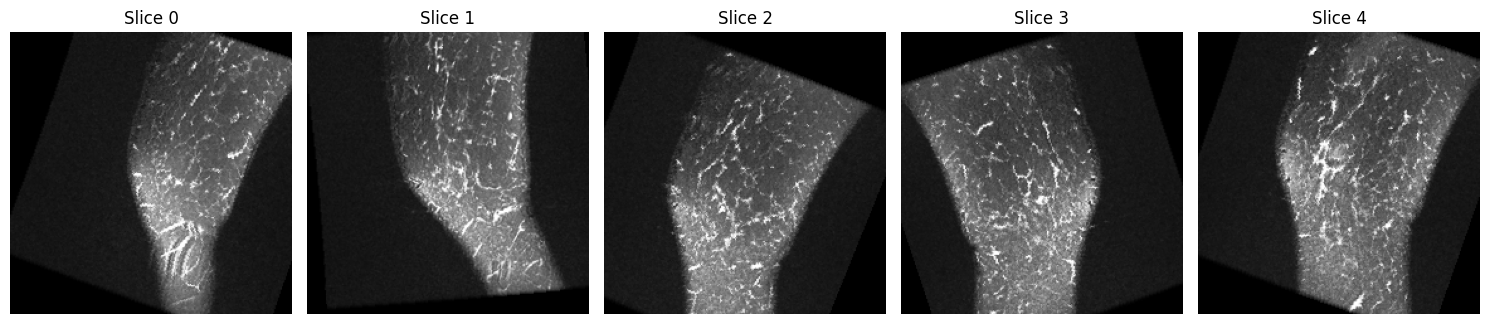

In [10]:

# Cell 10 — Inspect one exam

sample = train_ds[0]
print("Exam ID:", sample["id"])
print("Images shape:", sample["images"].shape)
print("Label:", sample["label"].item(), CFG.CLASS_NAMES[sample["label"].item()])
print("Num slices:", sample["images"].shape[0])

def denorm(x):
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    std = torch.tensor([0.25, 0.25, 0.25]).view(3,1,1)
    return x * std + mean

n_show = min(5, sample["images"].shape[0])
fig, axes = plt.subplots(1, n_show, figsize=(15, 4))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    img = np.clip(denorm(sample["images"][i]).permute(1,2,0).numpy(), 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Slice {sample['slice_idxs'][i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [11]:

# Cell 11 — Optional focal loss for multiclass

class MultiClassFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

In [12]:

# Cell 12 — Models

class SliceCNNExamClassifier(nn.Module):
    def __init__(self, backbone_name="resnet50", dropout=0.5, num_classes=4):
        super().__init__()

        if backbone_name == "resnet50":
            weights = tv_models.ResNet50_Weights.DEFAULT
            backbone = tv_models.resnet50(weights=weights)
            feat_dim = backbone.fc.in_features
            backbone.fc = nn.Identity()
            self.backbone = backbone

        elif backbone_name == "inception_v3":
            weights = tv_models.Inception_V3_Weights.DEFAULT
            backbone = tv_models.inception_v3(weights=weights, aux_logits=True)
            feat_dim = backbone.fc.in_features
            backbone.fc = nn.Identity()
            backbone.AuxLogits = None
            self.backbone = backbone
        else:
            raise ValueError("Unsupported backbone_name")

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)

        feats = self.backbone(x)
        if isinstance(feats, tuple):
            feats = feats[0]

        feats = feats.view(B, S, -1)
        exam_feat = feats.mean(dim=1)
        logits = self.classifier(exam_feat)
        return logits

class ViTSequenceClassifier(nn.Module):
    def __init__(self, vit_name="vit_small_patch16_224", depth=4, nhead=8, dropout=0.5, num_classes=4):
        super().__init__()

        self.image_encoder = timm.create_model(
            vit_name,
            pretrained=True,
            num_classes=0
        )
        feat_dim = self.image_encoder.num_features

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feat_dim,
            nhead=nhead,
            dim_feedforward=feat_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.sequence_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, feat_dim))
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):
        B, S, C, H, W = x.shape
        x = x.view(B * S, C, H, W)
        feats = self.image_encoder(x)
        feats = feats.view(B, S, -1)

        cls = self.cls_token.expand(B, -1, -1)
        seq = torch.cat([cls, feats], dim=1)
        seq = self.sequence_encoder(seq)
        cls_out = seq[:, 0]
        logits = self.classifier(cls_out)
        return logits

def build_model():
    if CFG.MODEL_TYPE == "resnet50":
        return SliceCNNExamClassifier("resnet50", dropout=CFG.DROPOUT, num_classes=CFG.NUM_CLASSES)
    elif CFG.MODEL_TYPE == "inception_v3":
        return SliceCNNExamClassifier("inception_v3", dropout=CFG.DROPOUT, num_classes=CFG.NUM_CLASSES)
    elif CFG.MODEL_TYPE == "vit_small":
        return ViTSequenceClassifier(
            vit_name=CFG.VIT_MODEL_NAME,
            depth=CFG.TRANSFORMER_DEPTH,
            nhead=CFG.TRANSFORMER_HEADS,
            dropout=CFG.DROPOUT,
            num_classes=CFG.NUM_CLASSES
        )
    elif CFG.MODEL_TYPE == "vit_large":
        return ViTSequenceClassifier(
            vit_name=CFG.VIT_LARGE_MODEL_NAME,
            depth=CFG.TRANSFORMER_DEPTH,
            nhead=16,
            dropout=CFG.DROPOUT,
            num_classes=CFG.NUM_CLASSES
        )
    else:
        raise ValueError("Unknown MODEL_TYPE")

In [13]:

# Cell 13 — Create model, loss, optimizer

model = build_model().to(CFG.DEVICE)

if CFG.USE_FOCAL_LOSS:
    criterion = MultiClassFocalLoss(
        alpha=class_weights.to(CFG.DEVICE),
        gamma=CFG.FOCAL_GAMMA,
        reduction="mean"
    )
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(CFG.DEVICE))

if CFG.MODEL_TYPE in ["vit_small", "vit_large"]:
    backbone_params = list(model.image_encoder.parameters())
    head_params = (
        list(model.sequence_encoder.parameters()) +
        [model.cls_token] +
        list(model.classifier.parameters())
    )
else:
    backbone_params = list(model.backbone.parameters())
    head_params = list(model.classifier.parameters())

optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": CFG.BACKBONE_LR},
        {"params": head_params, "lr": CFG.HEAD_LR},
    ],
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.EPOCHS
)

print(model.__class__.__name__)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViTSequenceClassifier


In [14]:

# Cell 14 — Metrics helpers

def multiclass_auc_ovr(y_true, y_prob, num_classes):
    try:
        return roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except:
        return np.nan

def compute_metrics(y_true, y_prob):
    y_pred = y_prob.argmax(axis=1)

    auc = multiclass_auc_ovr(y_true, y_prob, CFG.NUM_CLASSES)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {
        "auc_ovr_macro": auc,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1
    }, y_pred

In [15]:

# Cell 15 — Train / valid functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_targets = []
    all_probs = []

    for batch in loader:
        images = batch["images"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        probs = torch.softmax(logits, dim=1)
        all_targets.extend(labels.detach().cpu().numpy().reshape(-1).tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics, _ = compute_metrics(np.array(all_targets), np.array(all_probs))
    return epoch_loss, metrics

@torch.no_grad()
def valid_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []
    all_ids = []

    for batch in loader:
        images = batch["images"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * labels.size(0)

        probs = torch.softmax(logits, dim=1)
        all_targets.extend(labels.detach().cpu().numpy().reshape(-1).tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_ids.append(batch["id"][0])

    epoch_loss = running_loss / len(loader.dataset)
    metrics, y_pred = compute_metrics(np.array(all_targets), np.array(all_probs))

    return epoch_loss, metrics, np.array(all_targets), np.array(all_probs), np.array(y_pred), all_ids

In [16]:

# Cell 16 — Train loop

best_f1 = -1
best_model_path = f"/kaggle/working/best_multiclass_{CFG.MODEL_TYPE}_{CFG.PLANE}.pth"

history = {
    "train_loss": [],
    "train_auc": [],
    "valid_loss": [],
    "valid_auc": [],
    "valid_acc": [],
    "valid_bal_acc": [],
    "valid_macro_f1": []
}

for epoch in range(CFG.EPOCHS):
    train_loss, train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, CFG.DEVICE)
    valid_loss, valid_metrics, _, _, _, _ = valid_one_epoch(model, valid_loader, criterion, CFG.DEVICE)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_auc"].append(train_metrics["auc_ovr_macro"])
    history["valid_loss"].append(valid_loss)
    history["valid_auc"].append(valid_metrics["auc_ovr_macro"])
    history["valid_acc"].append(valid_metrics["accuracy"])
    history["valid_bal_acc"].append(valid_metrics["balanced_accuracy"])
    history["valid_macro_f1"].append(valid_metrics["macro_f1"])

    print(
        f"Epoch {epoch+1}/{CFG.EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train AUC: {train_metrics['auc_ovr_macro']:.4f} | "
        f"Valid Loss: {valid_loss:.4f} | Valid AUC: {valid_metrics['auc_ovr_macro']:.4f} | "
        f"Valid Acc: {valid_metrics['accuracy']:.4f} | "
        f"Valid Bal Acc: {valid_metrics['balanced_accuracy']:.4f} | "
        f"Valid Macro F1: {valid_metrics['macro_f1']:.4f}"
    )

    if valid_metrics["macro_f1"] > best_f1:
        best_f1 = valid_metrics["macro_f1"]
        torch.save(model.state_dict(), best_model_path)

print("Best model saved to:", best_model_path)
print("Best validation macro F1:", best_f1)

Epoch 1/12 | Train Loss: 1.4486 | Train AUC: 0.5549 | Valid Loss: 1.4554 | Valid AUC: 0.7877 | Valid Acc: 0.2750 | Valid Bal Acc: 0.3890 | Valid Macro F1: 0.2760
Epoch 2/12 | Train Loss: 1.2784 | Train AUC: 0.6649 | Valid Loss: 1.1235 | Valid AUC: 0.8234 | Valid Acc: 0.4833 | Valid Bal Acc: 0.5220 | Valid Macro F1: 0.4878
Epoch 3/12 | Train Loss: 1.2231 | Train AUC: 0.6953 | Valid Loss: 1.1810 | Valid AUC: 0.8131 | Valid Acc: 0.4833 | Valid Bal Acc: 0.5521 | Valid Macro F1: 0.4886
Epoch 4/12 | Train Loss: 1.1454 | Train AUC: 0.7351 | Valid Loss: 0.9353 | Valid AUC: 0.8353 | Valid Acc: 0.6417 | Valid Bal Acc: 0.5879 | Valid Macro F1: 0.5903
Epoch 5/12 | Train Loss: 1.1048 | Train AUC: 0.7506 | Valid Loss: 0.9869 | Valid AUC: 0.8346 | Valid Acc: 0.6167 | Valid Bal Acc: 0.5865 | Valid Macro F1: 0.5838
Epoch 6/12 | Train Loss: 1.0779 | Train AUC: 0.7652 | Valid Loss: 1.1961 | Valid AUC: 0.8348 | Valid Acc: 0.5667 | Valid Bal Acc: 0.5945 | Valid Macro F1: 0.5622
Epoch 7/12 | Train Loss: 1.0

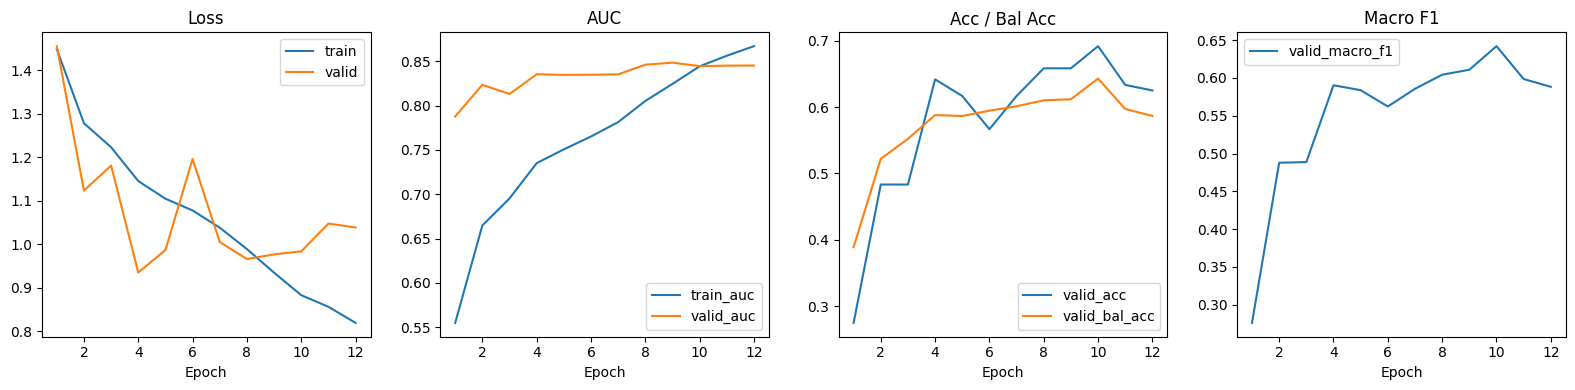

In [17]:

# Cell 17 — Plot curves

epochs = range(1, CFG.EPOCHS + 1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["valid_loss"], label="valid")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(epochs, history["train_auc"], label="train_auc")
plt.plot(epochs, history["valid_auc"], label="valid_auc")
plt.title("AUC")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(epochs, history["valid_acc"], label="valid_acc")
plt.plot(epochs, history["valid_bal_acc"], label="valid_bal_acc")
plt.title("Acc / Bal Acc")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(epochs, history["valid_macro_f1"], label="valid_macro_f1")
plt.title("Macro F1")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:

# Cell 18 — Final evaluation

model.load_state_dict(torch.load(best_model_path, map_location=CFG.DEVICE))
valid_loss, valid_metrics, y_true, y_prob, y_pred, exam_ids = valid_one_epoch(
    model, valid_loader, criterion, CFG.DEVICE
)

print("Final Validation Loss:", round(valid_loss, 4))
print("Final Validation AUC (macro OVR):", round(valid_metrics["auc_ovr_macro"], 4))
print("Final Validation Accuracy:", round(valid_metrics["accuracy"], 4))
print("Final Validation Balanced Accuracy:", round(valid_metrics["balanced_accuracy"], 4))
print("Final Validation Macro F1:", round(valid_metrics["macro_f1"], 4))

Final Validation Loss: 0.9839
Final Validation AUC (macro OVR): 0.8445
Final Validation Accuracy: 0.6917
Final Validation Balanced Accuracy: 0.6429
Final Validation Macro F1: 0.642


In [19]:

# Cell 19 — Confusion matrix and classification report

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print(cm)
print()

print(classification_report(
    y_true,
    y_pred,
    target_names=CFG.CLASS_NAMES,
    digits=4,
    zero_division=0
))

Confusion matrix:
[[44  6  3  1]
 [ 4 14  2  1]
 [ 3  4  9  4]
 [ 3  0  6 16]]

                precision    recall  f1-score   support

           acl     0.8148    0.8148    0.8148        54
      meniscus     0.5833    0.6667    0.6222        21
abnormal_other     0.4500    0.4500    0.4500        20
        normal     0.7273    0.6400    0.6809        25

      accuracy                         0.6917       120
     macro avg     0.6439    0.6429    0.6420       120
  weighted avg     0.6953    0.6917    0.6924       120



In [20]:

# Cell 20 — Save predictions and summary

pred_df = pd.DataFrame({
    "id": exam_ids,
    "true_label": y_true.astype(int),
    "pred_label": y_pred.astype(int),
    "true_name": [CFG.CLASS_NAMES[i] for i in y_true.astype(int)],
    "pred_name": [CFG.CLASS_NAMES[i] for i in y_pred.astype(int)],
    "prob_acl": y_prob[:, 0],
    "prob_meniscus": y_prob[:, 1],
    "prob_abnormal_other": y_prob[:, 2],
    "prob_normal": y_prob[:, 3],
})

pred_csv_path = f"/kaggle/working/preds_multiclass_{CFG.MODEL_TYPE}_{CFG.PLANE}.csv"
model_path = f"/kaggle/working/final_multiclass_{CFG.MODEL_TYPE}_{CFG.PLANE}.pth"

pred_df.to_csv(pred_csv_path, index=False)
torch.save(model.state_dict(), model_path)

results_df = pd.DataFrame([{
    "model_type": CFG.MODEL_TYPE,
    "plane": CFG.PLANE,
    "use_focal_loss": CFG.USE_FOCAL_LOSS,
    "focal_gamma": CFG.FOCAL_GAMMA if CFG.USE_FOCAL_LOSS else np.nan,
    "auc_ovr_macro": float(valid_metrics["auc_ovr_macro"]),
    "accuracy": float(valid_metrics["accuracy"]),
    "balanced_accuracy": float(valid_metrics["balanced_accuracy"]),
    "macro_f1": float(valid_metrics["macro_f1"]),
}])

print("Saved:", pred_csv_path)
print("Saved:", model_path)
results_df

Saved: /kaggle/working/preds_multiclass_vit_small_sagittal.csv
Saved: /kaggle/working/final_multiclass_vit_small_sagittal.pth


,model_type,plane,use_focal_loss,focal_gamma,auc_ovr_macro,accuracy,balanced_accuracy,macro_f1
0,vit_small,sagittal,False,NaN,0.84449,0.691667,0.64287,0.641972


## Suggested experiments

Change only `MODEL_TYPE` in the config cell:

- `"resnet50"`
- `"inception_v3"`
- `"vit_small"`
- `"vit_large"`

## Notes
- This notebook is **multi-class**, not multi-label.
- It uses an **exclusive priority rule** to force one class per exam.
- This is useful for direct coursework-style comparison, but less natural for MRNet than multi-label.
- If `vit_large` gives OOM:
  - keep `BATCH_SIZE = 1`
  - optionally limit slices in the dataset with `max_slices`

In [21]:

gc.collect()
torch.cuda.empty_cache()
print("Cleanup done.")

Cleanup done.
